In [42]:
# Titanic dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import classification_report as cr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import joblib as jb

Loading the Dataset ⏳

In [43]:
dataset = pd.read_csv("titanic.csv")
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [44]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [45]:
dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Preprocessing the Data 📈

In [46]:
print('Number of unique values: ', dataset.nunique(), "\n")
print('Number of total unique values: ', dataset.nunique().sum())

Number of unique values:  PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64 

Number of total unique values:  2970


In [47]:
dataset.duplicated().sum()

np.int64(0)

In [48]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [49]:
dataset.drop(['PassengerId'], axis = 1, inplace = True)
dataset

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [50]:
if 'Cabin' in dataset.columns:
    dataset.drop(['Cabin'], axis=1, inplace=True)
else:
    print("Note: 'Cabin' column not found in dataset")

In [51]:
dataset

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [52]:
dataset.drop(['Name'], axis=1, inplace=True)
dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


In [53]:
#handling missing values by using mean for age and mode for embarked
age_impute = SimpleImputer(strategy = 'mean')
dataset['Age'] = age_impute.fit_transform(dataset[['Age']])
embarked_impute = SimpleImputer(strategy = 'most_frequent')
dataset['Embarked'] = embarked_impute.fit_transform(dataset[['Embarked']]).ravel()
print(dataset['Age'], "\n")
print('null values in Age column: ', dataset['Age'].isnull().sum(), "\n")
print(dataset['Embarked'])
print('null values in Embarked column: ', dataset['Embarked'].isnull().sum(), "\n")

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64 

null values in Age column:  0 

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object
null values in Embarked column:  0 



In [54]:
dataset.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

Exploratory Data Analysis 📊

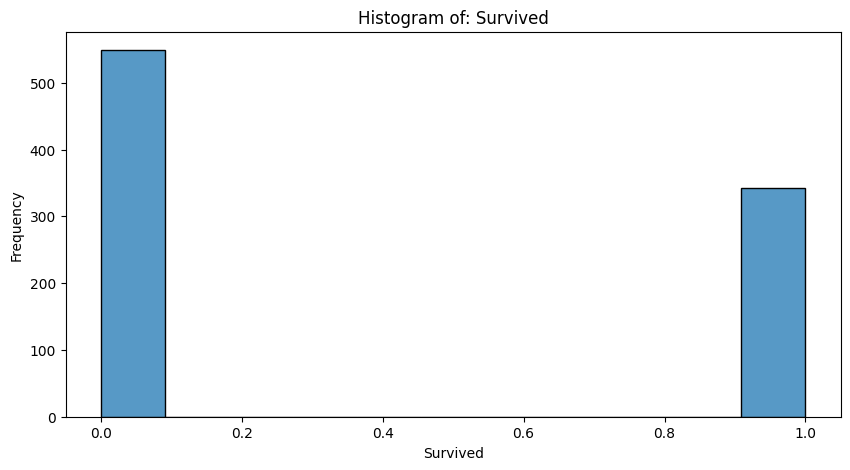

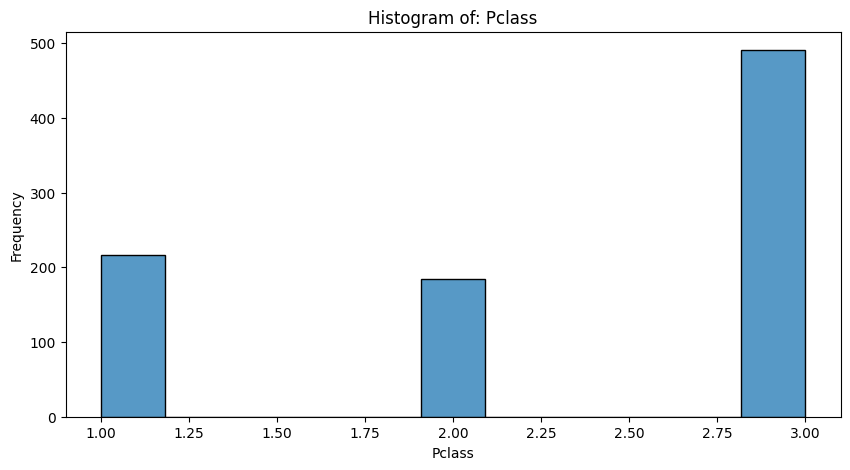

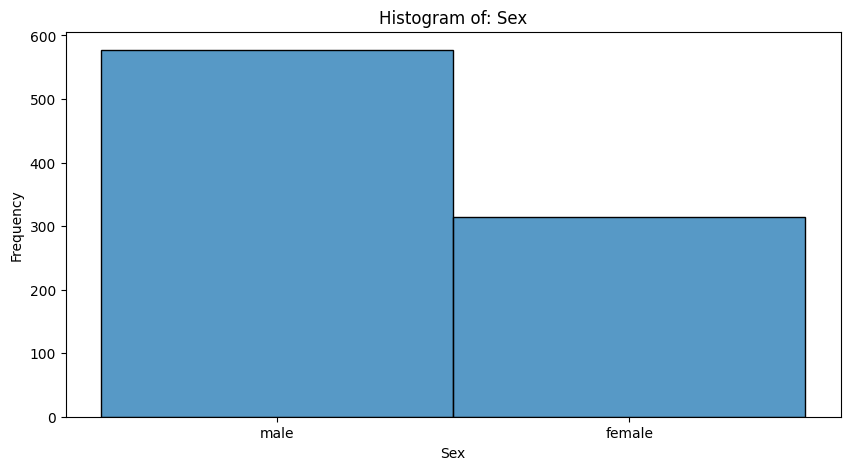

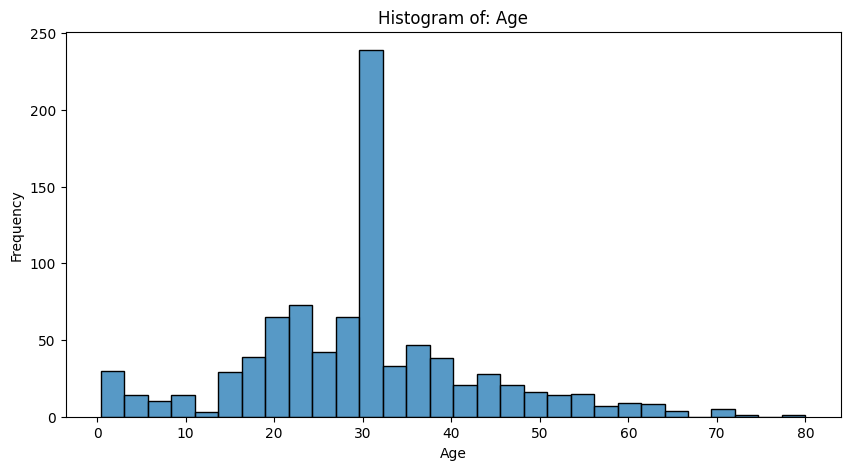

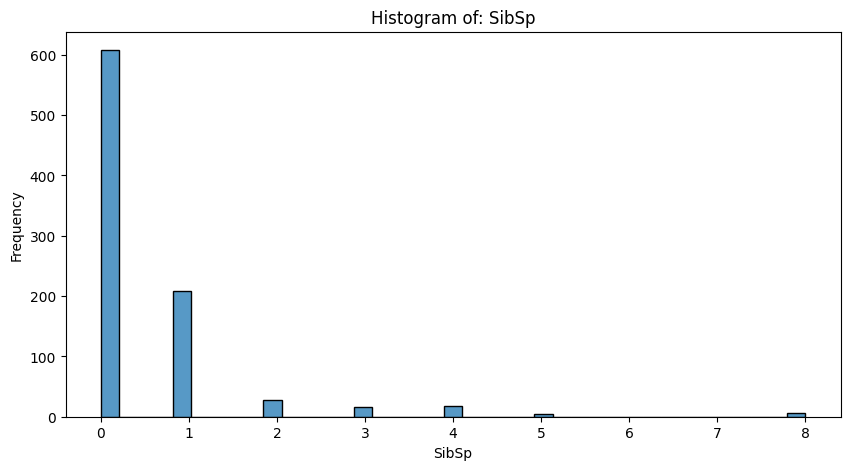

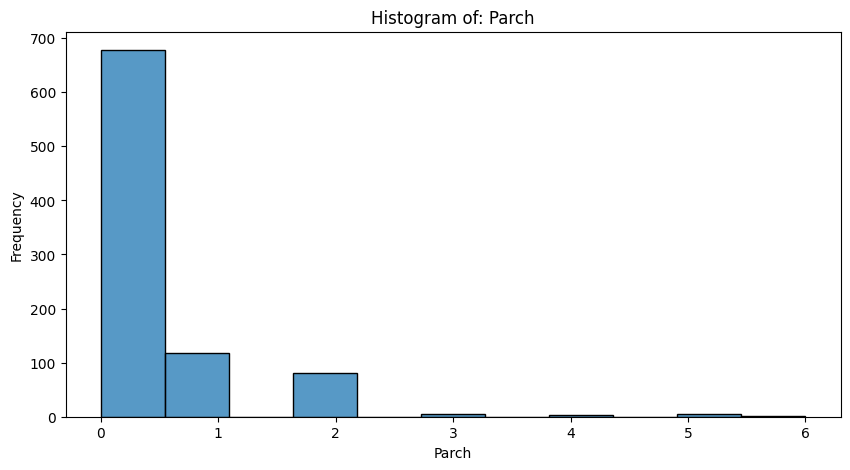

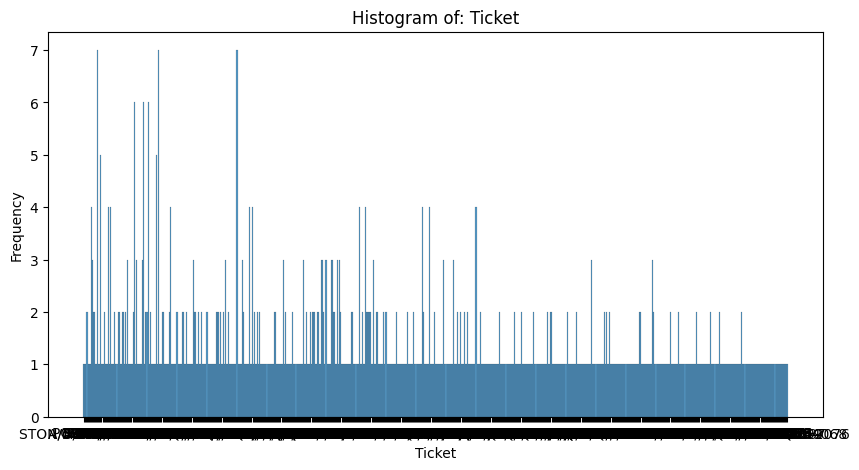

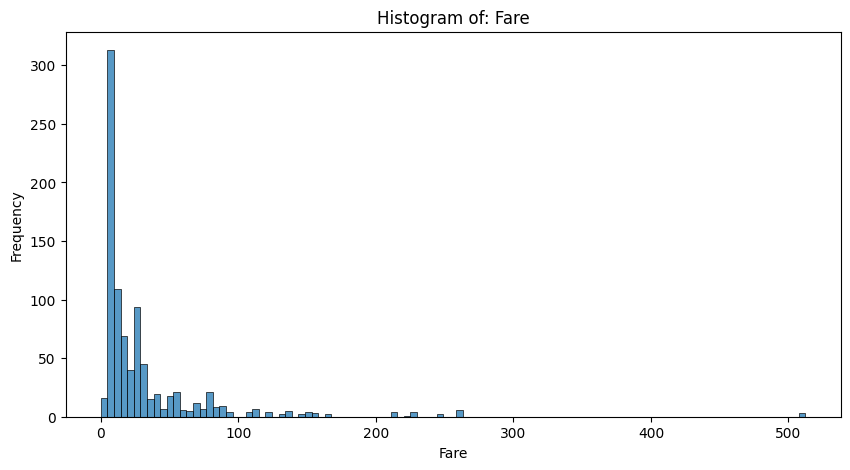

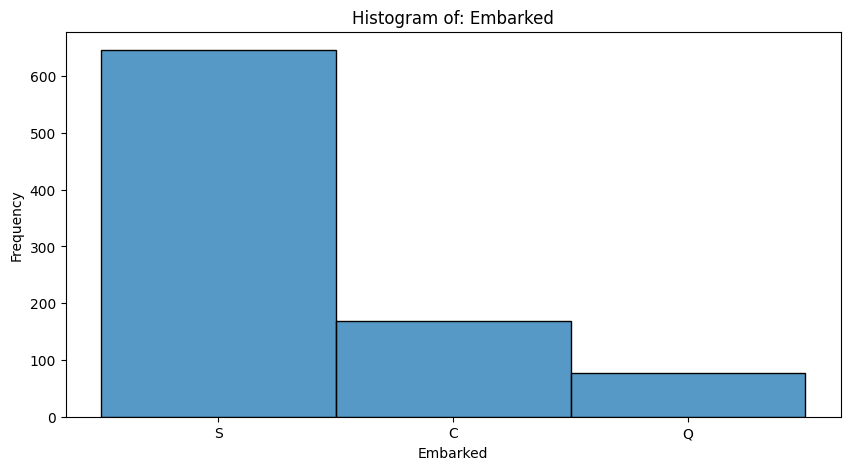

In [55]:
#Histogram
features = dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.histplot(dataset[feature])
    plt.title('Histogram of: ' + feature)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [58]:
#now encoding the categorical variables 
label_encoding = LabelEncoder()
dataset['Sex'] = label_encoding.fit_transform(dataset['Sex'])
dataset['Embarked'] = label_encoding.fit_transform(dataset['Embarked'])
dataset['Ticket'] = label_encoding.fit_transform(dataset['Ticket'])
dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,1,22.000000,1,0,523,7.2500,2
1,1,1,0,38.000000,1,0,596,71.2833,0
2,1,3,0,26.000000,0,0,669,7.9250,2
3,1,1,0,35.000000,1,0,49,53.1000,2
4,0,3,1,35.000000,0,0,472,8.0500,2
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,101,13.0000,2
887,1,1,0,19.000000,0,0,14,30.0000,2
888,0,3,0,29.699118,1,2,675,23.4500,2
889,1,1,1,26.000000,0,0,8,30.0000,0


In [59]:
#now plotting the correlation matrix
correlation_matrix = dataset.corr()
correlation_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
Survived,1.000000,-0.338481,-0.543351,-0.069809,-0.035322,0.081629,-0.164549,0.257307,-0.167675
Pclass,-0.338481,1.000000,0.131900,-0.331339,0.083081,0.018443,0.319869,-0.549500,0.162098
Sex,-0.543351,0.131900,1.000000,0.084153,-0.114631,-0.245489,0.059372,-0.182333,0.108262
Age,-0.069809,-0.331339,0.084153,1.000000,-0.232625,-0.179191,-0.068848,0.091566,-0.026749
SibSp,-0.035322,0.083081,-0.114631,-0.232625,1.000000,0.414838,0.079461,0.159651,0.068230
Parch,0.081629,0.018443,-0.245489,-0.179191,0.414838,1.000000,0.020003,0.216225,0.039798
Ticket,-0.164549,0.319869,0.059372,-0.068848,0.079461,0.020003,1.000000,-0.013885,-0.001729
Fare,0.257307,-0.549500,-0.182333,0.091566,0.159651,0.216225,-0.013885,1.000000,-0.224719
Embarked,-0.167675,0.162098,0.108262,-0.026749,0.068230,0.039798,-0.001729,-0.224719,1.000000


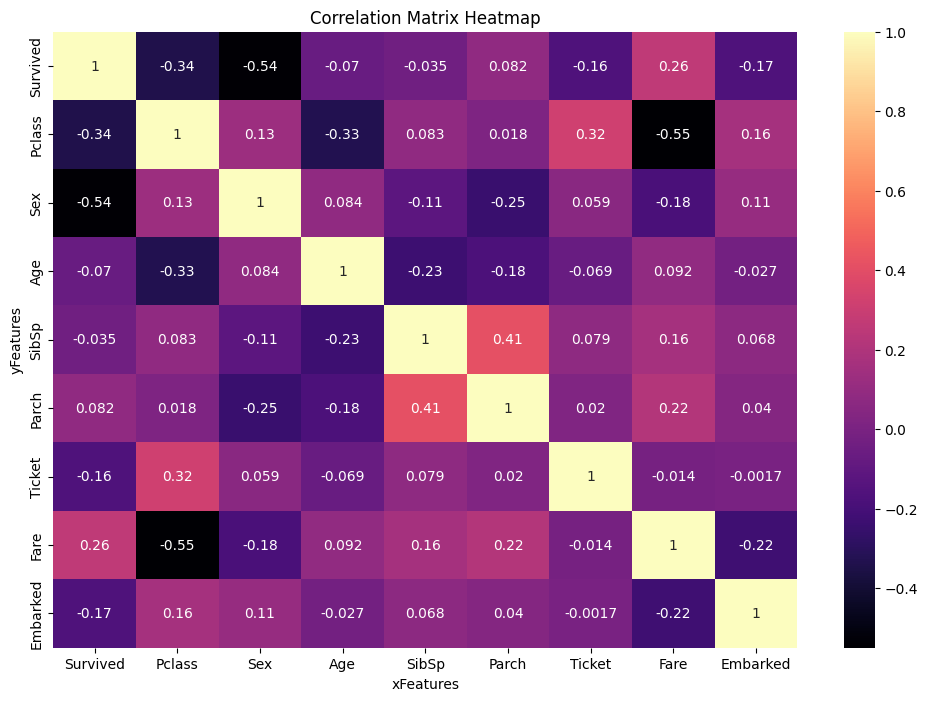

In [60]:
#now using heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap = 'magma')
plt.title('Correlation Matrix Heatmap')
plt.xlabel('xFeatures')
plt.ylabel('yFeatures')
plt.show()


In [61]:
#drop unnecessary columns
if 'Ticket' in dataset.columns:
    dataset.drop(['Ticket'], axis=1, inplace=True)
if 'SibSp' in dataset.columns:
    dataset.drop(['SibSp'], axis=1, inplace=True)
if 'Parch' in dataset.columns:
    dataset.drop(['Parch'], axis=1, inplace=True)
if 'Embarked' in dataset.columns:
    dataset.drop(['Embarked'], axis=1, inplace=True)
dataset

,Survived,Pclass,Sex,Age,Fare
0,0,3,1,22.000000,7.2500
1,1,1,0,38.000000,71.2833
2,1,3,0,26.000000,7.9250
3,1,1,0,35.000000,53.1000
4,0,3,1,35.000000,8.0500
...,...,...,...,...,...
886,0,2,1,27.000000,13.0000
887,1,1,0,19.000000,30.0000
888,0,3,0,29.699118,23.4500
889,1,1,1,26.000000,30.0000


Model Training 💪🏋️

1. Decision Tree

In [62]:
#train test split
X = dataset.drop('Survived', axis=1)
Y = dataset['Survived']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#now scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
#training the model 
model = DecisionTreeClassifier()
model.fit(X_train_scaled, Y_train)

DecisionTreeClassifier()

In [64]:
#evaluation of the model by using evaluation metrics
Actual_data = Y_test.values
Predicted_data = model.predict(X_test)
print ("Actual Data: ", Actual_data, "\n\n")
print ("Predicted Data: ", Predicted_data, "\n\n")

Actual Data:  [1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1] 


Predicted Data:  [0 1 1 1 1 1 1 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1
 1 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 1 1 0 0 0 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 0 0 1 0 1
 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 0 0 0 1 1] 




In [65]:
#claculating cross validation scores
scores = cross_val_score(model, X_train_scaled, Y_train, cv=5)
print("Cross-validation scores: ", scores, '\n')

best_score = 0
best_random_state = 0 

for i in range(20):  
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=i)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model.fit(X_train_scaled, Y_train)
    score = model.score(X_test_scaled, Y_test)
    
    if score > best_score:
        best_score = score
        best_random_state = i

print("Best random state number: ", best_random_state)
print("Best accuracy score: ", best_score, "\n")

Cross-validation scores:  [0.74125874 0.74125874 0.8028169  0.82394366 0.76056338] 

Best random state number:  17
Best accuracy score:  0.8156424581005587 



In [66]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=best_random_state)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, Y_train)
final_accuracy = model.score(X_test_scaled, Y_test)
print("Final model accuracy: ", final_accuracy * 100, "%")

Final model accuracy:  81.56424581005587 %


In [67]:
#mean cross validation score
scores = cross_val_score(model, X_train_scaled, Y_train, cv=5)
print("Mean Cross validation scores: ", scores.mean() * 100, "%")
mcvs = final_accuracy - scores.mean()
print("Mean Cross validation scores: ", mcvs * 100, "%")

Mean Cross validation scores:  79.63459076135132 %
Mean Cross validation scores:  1.9296550487045483 %


In [68]:
#classification report for decision tree
classification_report = cr(Y_test, Predicted_data)
print(classification_report)

              precision    recall  f1-score   support

           0       0.59      0.55      0.57       106
           1       0.40      0.44      0.42        73

    accuracy                           0.50       179
   macro avg       0.49      0.49      0.49       179
weighted avg       0.51      0.50      0.51       179



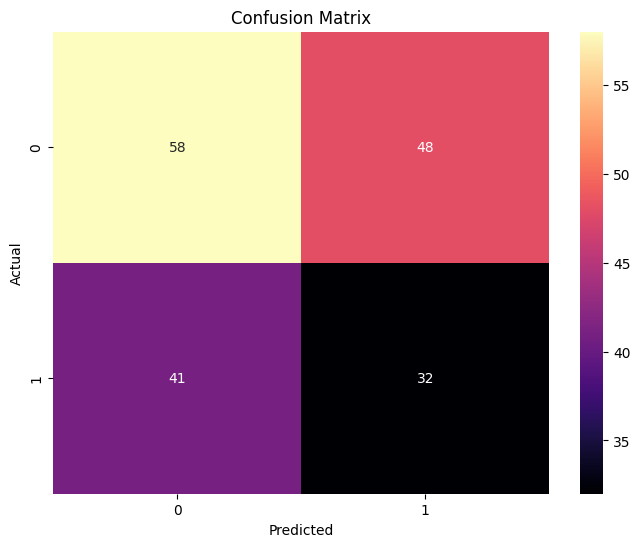

In [69]:
#confuson matrix for decision tree
confusion_matrix = cm(Y_test, Predicted_data)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

2. KNN MODEL

In [70]:
#train test data
X2 = dataset.drop('Survived', axis=1)
Y2 = dataset['Survived']
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X2, Y2, test_size=0.2, random_state=42)

#now scale features
scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

In [71]:
#now train knn model
model2 = KNeighborsClassifier(n_neighbors = 3)
model2.fit(X_train_scaled2, Y_train2)

KNeighborsClassifier(n_neighbors=3)

In [72]:
Actual_valus2 = Y_test2.values
Predicted_values2 = model2.predict(X_test)
print ("Actual Data: ", Actual_valus2, "\n\n")
print ("Predicted Data: ", Predicted_values2, "\n\n")

Actual Data:  [1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1] 


Predicted Data:  [0 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 0 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 1 1 1 1 0 1 1 1 1 0 0 1
 1 0 1 0 0 0 0 1 1 0 0 0 1 1 1 0 0 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0
 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1
 1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 1 0 0 1 1] 




/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [73]:
scores2 = cross_val_score(model2, X_train_scaled2, Y_train2, cv=5)
print("Cross-validation scores for KNN: ", scores2, '\n')

best_score2 = 0
best_random_state2 = 0

for i in range(20):
    X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X2, Y2, test_size=0.2, random_state=i)
    scaler2 = StandardScaler()
    X_train_scaled2 = scaler2.fit_transform(X_train)
    X_test_scaled2 = scaler2.transform(X_test)
    model2.fit(X_train_scaled2, Y_train2)
    score2 = model2.score(X_test_scaled2, Y_test2)
    if score2 > best_score2:
        best_score2 = score2
        best_random_state2 = i

print("Best random state number for KNN: ", best_random_state2)
print("Best accuracy score for KNN: ", best_score2, "\n")

Cross-validation scores for KNN:  [0.83916084 0.81818182 0.78873239 0.82394366 0.78873239] 

Best random state number for KNN:  17
Best accuracy score for KNN:  0.8268156424581006 



In [74]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X2, Y2, test_size=0.2, random_state=best_random_state2)

scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train)
X_test_scaled2 = scaler2.transform(X_test)

model2.fit(X_train_scaled2, Y_train2)
final_accuracy2 = model2.score(X_test_scaled2, Y_test2)
print("Final model accuracy for KNN: ", final_accuracy2 * 100, "%")

Final model accuracy for KNN:  82.68156424581005 %


In [75]:
#mean cross validation score
scores2 = cross_val_score(model2, X_train_scaled2, Y_train2, cv=5)
print("Mean Cross validation scores: ", scores.mean() * 100, "%")
mcvs2 = final_accuracy2 - scores2.mean()
print("Mean Cross validation scores: ", mcvs2 * 100, "%")

Mean Cross validation scores:  79.63459076135132 %
Mean Cross validation scores:  0.8023167327597225 %


In [76]:
#classification report
classification_report2 = cr(Y_test2, Predicted_values2)
print(classification_report2)

              precision    recall  f1-score   support

           0       0.81      0.58      0.67       106
           1       0.57      0.81      0.67        73

    accuracy                           0.67       179
   macro avg       0.69      0.69      0.67       179
weighted avg       0.71      0.67      0.67       179



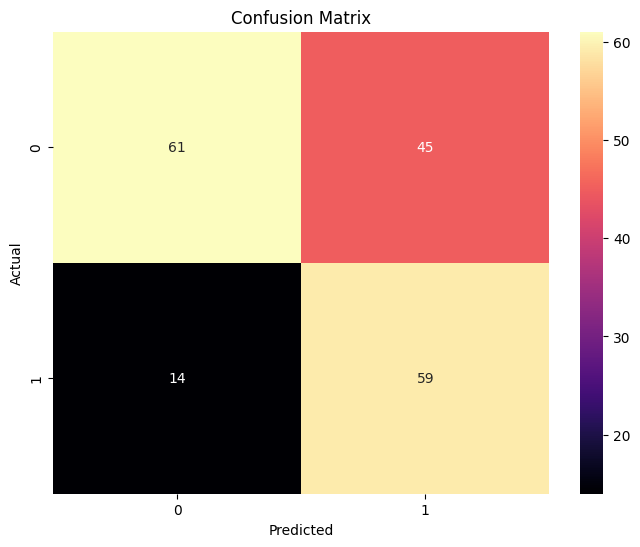

In [77]:
#confusion matrix
confusion_matrix2 = cm(Y_test2, Predicted_values2)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix2, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

3. Naive Bayes 

In [78]:
#train test data
X3 = dataset.drop('Survived', axis=1)
Y3 = dataset['Survived']
X_train3, X_test3, Y_train3, Y_test3 = train_test_split(X3, Y3, test_size=0.2, random_state=42)

#now scale features
scaler3 = StandardScaler()
X_train_scaled3 = scaler3.fit_transform(X_train3)
X_test3 = scaler3.transform(X_test3)

In [79]:
#now train naive bayes
model3 = GaussianNB()
model3.fit(X_train_scaled, Y_train)

GaussianNB()

In [80]:
#now check for actual and predict
Actual_valus3 = Y_test3.values
Predicted_values3 = model3.predict(X_test3)
print ("Actual Data: ", Actual_valus3, "\n\n")
print ("Predicted Data: ", Predicted_values3, "\n\n")

Actual Data:  [1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1] 


Predicted Data:  [0 0 0 1 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1] 




In [81]:
#cross validation score
scores3 = cross_val_score(model3, X_train_scaled3, Y_train3, cv=5)
print("Cross-validation scores for Naive Bayes: ", scores3, '\n')

best_score3 = 0
best_random_state3 = 0

for i in range(20):
    X_train3, X_test3, Y_train3, Y_test3 = train_test_split(X3, Y3, test_size=0.2, random_state=i)
    scaler3 = StandardScaler()
    X_train_scaled3 = scaler3.fit_transform(X_train3)
    X_test_scaled3 = scaler3.transform(X_test3)
    model3.fit(X_train_scaled3, Y_train3)
    score3 = model3.score(X_test_scaled3, Y_test3)
    if score3 > best_score3:
        best_score3 = score3
        best_random_state3 = i

print("Best random state number for Naive Bayes: ", best_random_state3)
print("Best accuracy score for Naive Bayes: ", best_score3, "\n")

Cross-validation scores for Naive Bayes:  [0.8041958  0.81818182 0.73943662 0.73239437 0.80985915] 

Best random state number for Naive Bayes:  11
Best accuracy score for Naive Bayes:  0.8324022346368715 



In [82]:
#final model training 
X_train3, X_test3, Y_train3, Y_test3 = train_test_split(X3, Y3, test_size=0.2, random_state=best_random_state3)

scaler3 = StandardScaler()
X_train_scaled3 = scaler3.fit_transform(X_train3)
X_test_scaled3 = scaler3.transform(X_test3)

model3.fit(X_train_scaled3, Y_train3)
final_accuracy3 = model3.score(X_test_scaled3, Y_test3)
print("Final model accuracy for Naive Bayes: ", final_accuracy3 * 100, "%")

Final model accuracy for Naive Bayes:  83.24022346368714 %


In [83]:
#mean cross validation score
scores3 = cross_val_score(model3, X_train_scaled3, Y_train3, cv=5)
print("Mean Cross validation scores: ", scores3.mean() * 100, "%")
mcvs3 = final_accuracy3 - scores3.mean()
print("Mean Cross validation scores: ", mcvs3 * 100, "%")

Mean Cross validation scores:  76.26612823795922 %
Mean Cross validation scores:  6.974095225727927 %


In [84]:
#classification report
classification3 = cr(Y_test3, Predicted_values3)
print(classification3)

              precision    recall  f1-score   support

           0       0.67      0.60      0.63       118
           1       0.36      0.43      0.39        61

    accuracy                           0.54       179
   macro avg       0.51      0.51      0.51       179
weighted avg       0.56      0.54      0.55       179



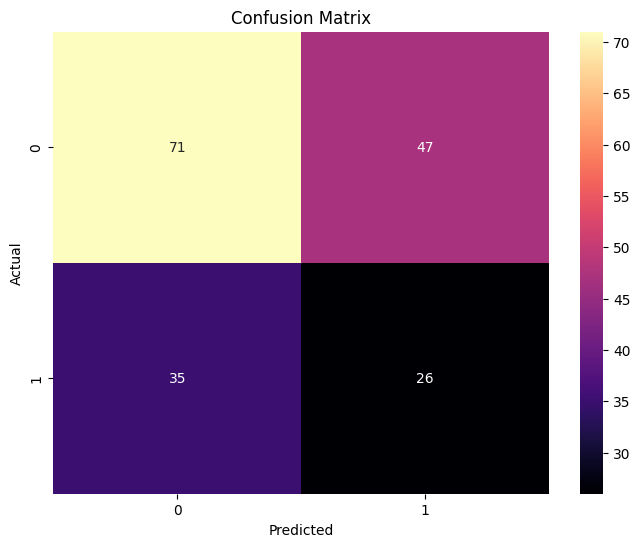

In [85]:
#confusion matrix
confusion_matrix3 = cm(Y_test3, Predicted_values3)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix3, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [86]:
#dumping of python objects
jb.dump(model, 'model.joblib')
jb.dump(scaler, 'scaler.joblib')
jb.dump(model2, 'model2.joblib')
jb.dump(scaler2, 'scaler2.joblib')
jb.dump(model3, 'model3.joblib')
jb.dump(scaler3, 'scaler3.joblib')

['scaler3.joblib']

#